# Analysis - Low-Demand, High-Supply Book Analysis
**Author**: Vuk

## Goal: 
The analysis indentifies books that have the large number of available copies but are rarely borrowed, pointing to potential overstock or low reader internet.

# Step 1: Import required libraris

We aregoing to use Pandas to load the data, and Matplotlib and Seaborn to create the charts.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the dataset
We will use a dataset containing information about books:

catalog_position,title,author,year_published,genre,section,total_copies,times_borrowed,last_borrowed_date,rating,ratings_count,price,language,page_count,dimensions_width,dimensions_thickness,dimensions_height,catalog_shelf,catalog_row,catalog_row_number


In [36]:
df = pd.read_csv("books.csv")

## Step 3: Show some sample data
Show first 5 rows

In [37]:
df.head()

,catalog_position,title,author,year_published,genre,section,total_copies,times_borrowed,last_borrowed_date,rating,ratings_count,price,language,page_count,dimensions_width,dimensions_thickness,dimensions_height,catalog_shelf,catalog_row,catalog_row_number
0,A1-B1-0001,Enormous Room,E. E. Cummings,1949.0,Drama,Fiction,5.0,3.0,1/6/2025,4.14,2.0,14.66,en,249.0,4.98,0.60,7.97,A1,B1,1
1,A1-B1-0002,Plutarchi Vitae parallelae,Plutarch,1478.0,Biography & Autobiography,History,4.0,1.0,3/19/2024,NaN,NaN,9.99,en,241.0,5.74,1.12,8.08,A1,B1,2
2,A1-B1-0003,The water-babies,Charles Kingsley,1863.0,Fantasy,Children,6.0,6.0,6/5/2024,4.21,6.0,13.89,en,228.0,7.70,0.70,5.10,A1,B1,3
3,A1-B1-0004,Kipps,H. G. Wells,1900.0,Comedy,Fiction,4.0,5.0,11/6/2024,4.44,4.0,370.00,en,386.0,5.08,0.98,7.80,A1,B1,4
4,A1-B1-0005,Man and Superman,George Bernard Shaw,1903.0,Drama,Fiction,5.0,2.0,1/16/2025,4.46,2.0,10.99,en,220.0,5.08,1.22,7.80,A1,B1,5


## Step 4: Ighnore rare books
We are going to exclude rare books, as they are not intended for borrowing.

In [38]:
df = df[df['section'] != 'Rare Books']

## Step 5: Calculate total copies / times barrowed ratio
We are going to create new column (borrowings_per_copy) with *times borrowed* to *total copies* ratio:

In [39]:
df['borrowings_per_copy'] = df['times_borrowed'] / df['total_copies']

## Step 6: Clean data

We are going to clean our data.

In [40]:
df.dropna(subset="borrowings_per_copy", inplace=True)
df = df[df["title"] != "Uknown Title"]

## Step 7: Sort and select final results
We are going to sort the values (ascending), select last 50 and print the final results.

In [41]:
sorted_df = df.sort_values(by='borrowings_per_copy', ascending=False)
bottom_50 = sorted_df.tail(50)

## Step 8: Show results

We will use our data to create bar charts and presents the final results.

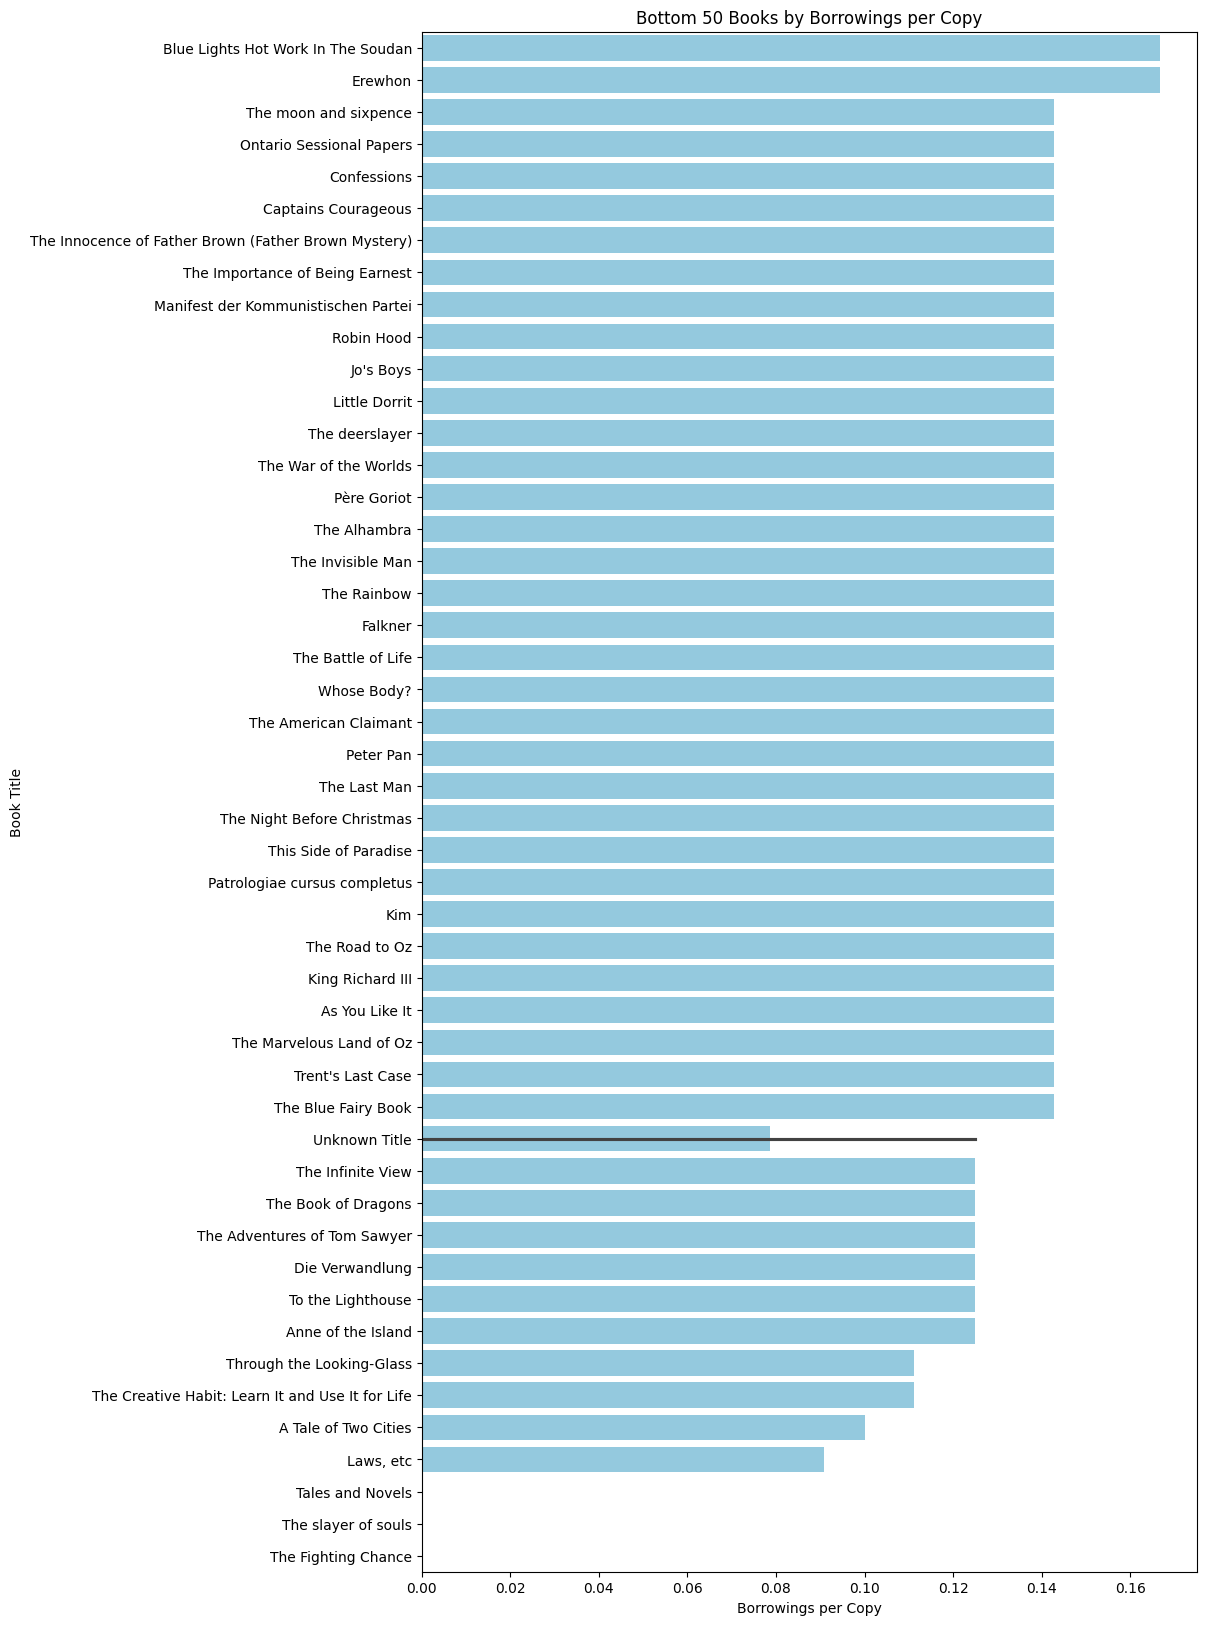

In [42]:
plt.figure(figsize=(10,20))

sns.barplot(
    data = bottom_50,
    x="borrowings_per_copy",
    y="title",
    color="skyblue"
)

plt.title("Bottom 50 Books by Borrowings per Copy")
plt.xlabel("Borrowings per Copy")
plt.ylabel("Book Title")
plt.show()

## Conclusion

The tablew abovce presents books with the **lowest borrowing rates relative to the number of available copies**
These titles represent **underutilized items** in the library's collection - books that occupy shelf space generate little reader engagement.

This insight is valuable for:
- **collection optimization** - identifying titles that may need to be replaced, promoted or removed,
- **inventory planning** - avoiding future overstocking of low-demand materials,
- and **data-driven decision-making** in library management.